# P07. Equation of State and Temperature

A layer's equation of state (EOS) relates pressure, temperature, and density. A constant-density layer gives a uniform interior, while a compressible EOS lets density increase with pressure toward the center. Temperature enters a layer's material through switches on the layer, each off by default, the simplest and fastest case:

| Switch | Effect when on |
|---|---|
| `use_thermal_expansion` | Density falls with temperature through the EOS's thermal expansivity. |
| `use_melting` | The material melts between its solidus and liquidus, weakening its shear modulus and viscosity. |
| `use_pressure_melting` | The melting curves follow the local pressure instead of their zero-pressure values. |
| `use_melt_density` | The density mixes in the liquid phase's density by melt fraction. |

This notebook compares a constant-density interior with a compressible Birch-Murnaghan one and then warms the Birch-Murnaghan mantle with thermal expansion on. It then warms a mantle through its melting range and tracks its shear modulus, which controls the tidal dissipation. Finally, it lets the melting curves follow the pressure, so only part of the mantle melts and the layer splits into solid and liquid zones.

As in notebook P06, the worlds are assembled by hand with `TerrestrialWorld` and `Layer`. Use the TOML-driven `build_world` (demo B02) when a standard configuration is enough.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.Material import Material, Phase, load_material
from TidalPy.Structures import Layer, TerrestrialWorld

RADIUS, MASS = 6.371e6, 5.972e24  # [m], [kg]


def rock_phase(eos):
    "A solid rock phase: the given equation of state, an 80 GPa shear modulus, and a Maxwell rheology."
    return Phase(
        eos=eos,
        shear_modulus={"model": "constant", "shear_modulus_pa": 80.0e9},
        shear_viscosity={"model": "constant", "reference_viscosity_pas": 1.0e21},
        shear_rheology="maxwell")


def build_terrestrial(material, temperature=1500.0, mass=MASS, **switches):
    "A one-mantle world of the given material, stated mass [kg], and layer switches, solved for its interior."
    world = TerrestrialWorld("planet", RADIUS, mass)
    world.add_layer(Layer(
        "mantle",
        radius_outer=RADIUS,
        material=material,
        temperature=temperature,
        **switches))
    world.solve_eos(raise_on_fail=True)  # Raises if the structure solve fails
    return world

## Constant Density vs a Compressible EOS

Both worlds have the same radius and state Earth's mass. The Birch-Murnaghan density increases with depth, while the constant-density profile stays flat. Each world's central pressure follows from its equation of state and reference density. The worlds are not fitted to one mass: the Birch-Murnaghan world holds 14% less. TidalPy warns once per world when a solved mass is more than 1% off the stated mass, as it does below. The later Birch-Murnaghan worlds state this solved mass instead.

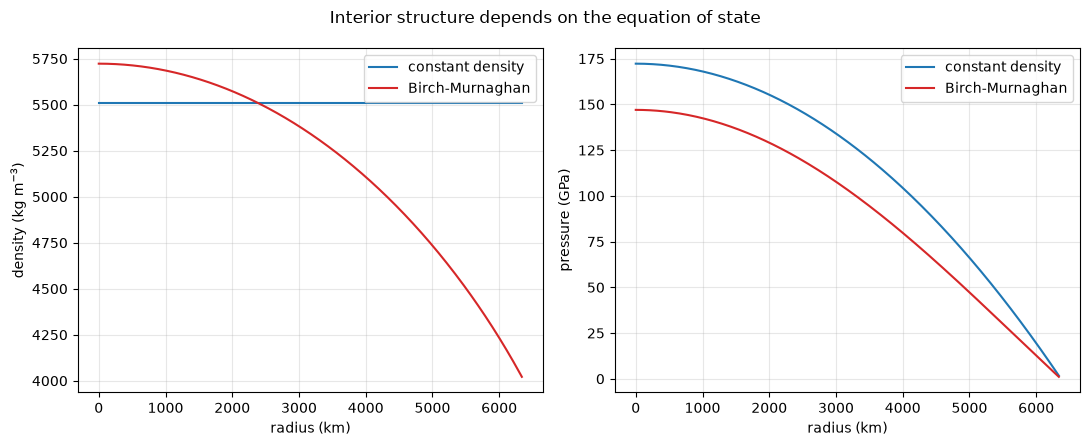

[TidalPy] [warning] TidalPy: world 'planet' solved to a mass of 5.135409e+24 kg, 14.0 percent off its stated mass of 5.972000e+24 kg. Its Love numbers, tides, and moment of inertia follow the solved structure, while its orbit in a System, calc_surface_gravity, and calc_mean_density use the stated mass. Adjust the layers' materials or radii, or the stated mass, so the two agree. Shown once per world.


central pressure (constant density): 172.3 GPa, mass 5.968e+24 kg
central pressure (Birch-Murnaghan) : 147.0 GPa, mass 5.135e+24 kg


In [2]:
constant_rock = Material(solid=rock_phase(
    {"model": "constant", "reference_density_kg_m3": 5510.0, "bulk_modulus_pa": 200.0e9}))
bm_eos = {"model": "birch_murnaghan", "reference_density_kg_m3": 4000.0, "reference_bulk_modulus_pa": 200.0e9,
          "bulk_modulus_derivative": 4.0}
const_world = build_terrestrial(constant_rock)
bm_world = build_terrestrial(Material(solid=rock_phase(bm_eos)))
bm_mass = bm_world.planet_mass_eos  # [kg] stated mass of the later Birch-Murnaghan worlds

radii = np.linspace(1.0, 0.995 * RADIUS, 300)
radii_km = radii / 1.0e3

fig, (ax_rho, ax_p) = plt.subplots(1, 2, figsize=(11, 4.5))
for world, label, color in [(const_world, "constant density", "tab:blue"),
                            (bm_world, "Birch-Murnaghan", "tab:red")]:
    ax_rho.plot(radii_km, world.get_density(radii), color=color, label=label)
    ax_p.plot(radii_km, world.get_pressure(radii) / 1.0e9, color=color, label=label)
ax_rho.set_ylabel("density (kg m$^{-3}$)")
ax_p.set_ylabel("pressure (GPa)")
for ax in (ax_rho, ax_p):
    ax.set_xlabel("radius (km)"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Interior structure depends on the equation of state")
fig.tight_layout()
plt.show()

print(f"central pressure (constant density): {const_world.central_pressure/1e9:.1f} GPa, "
      f"mass {const_world.planet_mass_eos:.3e} kg")
print(f"central pressure (Birch-Murnaghan) : {bm_world.central_pressure/1e9:.1f} GPa, "
      f"mass {bm_world.planet_mass_eos:.3e} kg")

## Thermal Expansion

Every EOS law carries a thermal expansivity $\alpha$ \[1/K\] and the reference temperature its other parameters hold at. With the layer's `use_thermal_expansion` off, the density ignores temperature. With it on, the material expands as it warms past the reference temperature, here $\alpha = 3\times10^{-5}$ 1/K from 300 K. The Birch-Murnaghan mantle is solved at three temperatures with the switch on, and once at 2500 K with it off. Each world states the cold mass from above, so the mass warning flags the two warm worlds that expand.

300 K, use_thermal_expansion = True     : central pressure  147.0 GPa, mass 5.135e+24 kg
1500 K, use_thermal_expansion = True    : central pressure  139.9 GPa, mass 4.993e+24 kg
2500 K, use_thermal_expansion = True    : central pressure  133.5 GPa, mass 4.863e+24 kg
2500 K, use_thermal_expansion = False   : central pressure  147.0 GPa, mass 5.135e+24 kg


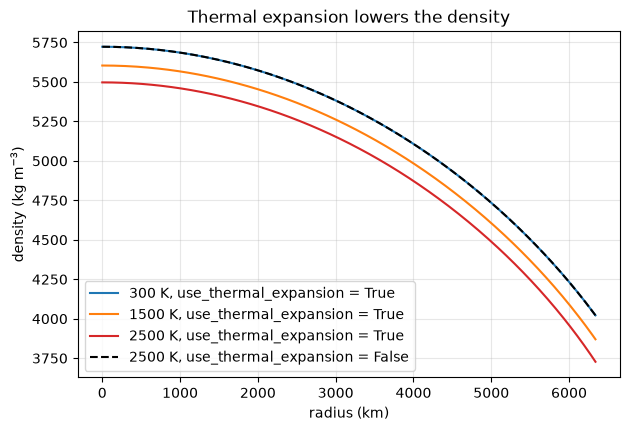

[TidalPy] [warning] TidalPy: world 'planet' solved to a mass of 4.993122e+24 kg, 2.8 percent off its stated mass of 5.135409e+24 kg. Its Love numbers, tides, and moment of inertia follow the solved structure, while its orbit in a System, calc_surface_gravity, and calc_mean_density use the stated mass. Adjust the layers' materials or radii, or the stated mass, so the two agree. Shown once per world.
[TidalPy] [warning] TidalPy: world 'planet' solved to a mass of 4.863188e+24 kg, 5.3 percent off its stated mass of 5.135409e+24 kg. Its Love numbers, tides, and moment of inertia follow the solved structure, while its orbit in a System, calc_surface_gravity, and calc_mean_density use the stated mass. Adjust the layers' materials or radii, or the stated mass, so the two agree. Shown once per world.


In [3]:
expanding_rock = Material(solid=rock_phase(
    {**bm_eos, "thermal_expansion_1_k": 3.0e-5, "reference_temperature_k": 300.0}))

fig, ax = plt.subplots(figsize=(7, 4.5))
for temperature, expansion, color, line in [(300.0, True, "tab:blue", "-"), (1500.0, True, "tab:orange", "-"),
                                            (2500.0, True, "tab:red", "-"), (2500.0, False, "k", "--")]:
    world = build_terrestrial(expanding_rock, temperature=temperature, mass=bm_mass, use_thermal_expansion=expansion)
    label = f"{temperature:.0f} K, use_thermal_expansion = {expansion}"
    ax.plot(radii_km, world.get_density(radii), color=color, ls=line, label=label)
    print(f"{label:40s}: central pressure {world.central_pressure/1e9:6.1f} GPa, "
          f"mass {world.planet_mass_eos:.3e} kg")
ax.set_xlabel("radius (km)")
ax.set_ylabel("density (kg m$^{-3}$)")
ax.set_title("Thermal expansion lowers the density")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

At its 300 K reference temperature the expanding mantle matches the cold one. At 2500 K it is about 4% lighter at mid-depth and 7% lighter at the surface, so with the radius fixed the world holds 5% less mass and its central pressure falls from 147 to 134 GPa. With the switch off, 2500 K changes nothing.

## Warming the Mantle Through Its Melting Range

A material with both a solid and a liquid phase melts between its solidus and liquidus (here constant, 1600 and 2000 K). A melt-weakening law sets how the shear modulus and viscosity fall with melt. The Henning law used here weakens them gradually up to a critical melt fraction (50%) and then collapses them toward the liquid's values. With the layer's `use_melting` on, a softer mantle deforms more under the tide.

The sweep below raises the uniform mantle temperature through the melting range, re-solving the same world at each temperature, and reads the post-melt properties at mid-depth. It also reads the world's zones: the stretches of the layer that the radial solver treats as solid or liquid.

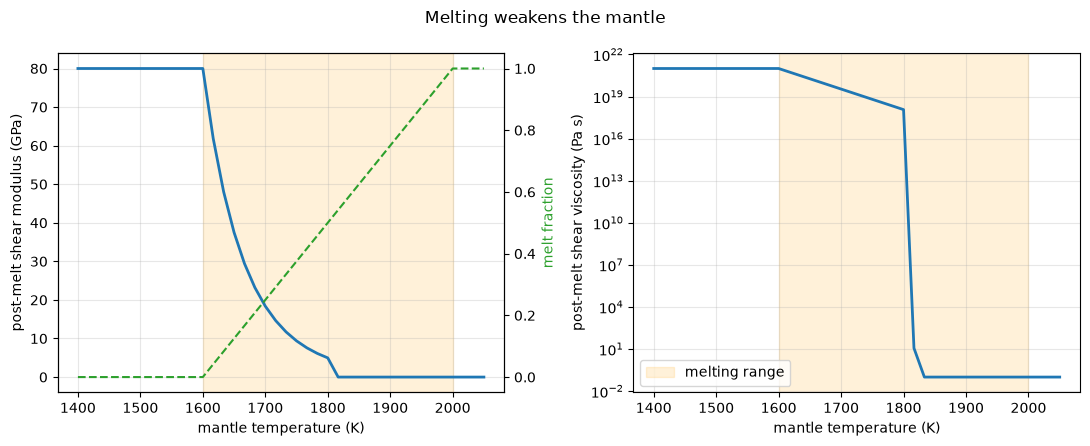

shear modulus at 1400 K: 80.0 GPa
shear modulus at 2050 K: 0.0 GPa
the mantle is one liquid zone from 1817 K


In [4]:
liquid_rock = Phase(
    eos={"model": "constant", "reference_density_kg_m3": 5000.0, "bulk_modulus_pa": 1.0e11},
    shear_viscosity={"model": "constant", "reference_viscosity_pas": 0.1})
melting_rock = Material(
    solid=constant_rock.solid,
    liquid=liquid_rock,
    solidus={"model": "constant", "temperature_k": 1600.0},
    liquidus={"model": "constant", "temperature_k": 2000.0},
    weakening="henning")

temperatures = np.linspace(1400.0, 2050.0, 40)
mid_radius = 0.5 * RADIUS
melt_world = build_terrestrial(melting_rock, temperature=temperatures[0], use_melting=True)

shear, viscosity, melt_fraction, liquid_from = [], [], [], None
for temperature in temperatures:
    melt_world.mantle.temperature = temperature  # Layers are accessed by name
    melt_world.solve_eos(raise_on_fail=True)
    state = melt_world.get_state(mid_radius)
    shear.append(state["shear_modulus"])
    viscosity.append(state["shear_viscosity"])
    melt_fraction.append(state["melt_fraction"])
    if liquid_from is None and melt_world.zones[0]["state"] == "liquid":
        liquid_from = temperature

fig, (ax_mu, ax_eta) = plt.subplots(1, 2, figsize=(11, 4.5))
ax_mu.plot(temperatures, np.array(shear) / 1.0e9, lw=2)
ax_mu.set_ylabel("post-melt shear modulus (GPa)")
ax_eta.semilogy(temperatures, viscosity, lw=2)
ax_eta.set_ylabel("post-melt shear viscosity (Pa s)")
ax_phi = ax_mu.twinx()
ax_phi.plot(temperatures, melt_fraction, color="tab:green", ls="--")
ax_phi.set_ylabel("melt fraction", color="tab:green")
for ax in (ax_mu, ax_eta):
    ax.axvspan(1600.0, 2000.0, color="orange", alpha=0.15, label="melting range")
    ax.set_xlabel("mantle temperature (K)")
    ax.grid(alpha=0.3)
ax_eta.legend(loc="lower left")
fig.suptitle("Melting weakens the mantle")
fig.tight_layout()
plt.show()

print(f"shear modulus at {temperatures[0]:.0f} K: {shear[0]/1e9:.1f} GPa")
print(f"shear modulus at {temperatures[-1]:.0f} K: {shear[-1]/1e9:.1f} GPa")
print(f"the mantle is one liquid zone from {liquid_from:.0f} K")

Below the solidus nothing changes: the solid's viscosity is constant here, so temperature acts only through melt. A temperature-dependent viscosity law (such as `arrhenius`, or the `reference` law the bundled worlds use) would also lower the viscosity, and raise the dissipation, as the solid warms. Through the first half of the melting range the shear modulus and viscosity fall steadily with melt. At 1800 K the melt fraction reaches the Henning law's critical value and the solid framework breaks down: across the breakdown band (50 to 55% melt) the shear modulus and viscosity drop to the liquid's (no rigidity, 0.1 Pa s). Once the rigidity falls below `minimum_solid_rigidity` times the world's $\rho g R$ (a `[numerical]` setting of the configuration), the whole mantle becomes one liquid zone, here from the first sweep temperature past 1800 K.

## Pressure Melting and Zones

Real melting curves rise with pressure. With `use_pressure_melting` on, the solidus and liquidus are read at the local pressure, so a uniformly warm mantle melts near the surface but stays solid at depth. The EOS solve then splits the layer into a solid zone and a liquid zone where the rigidity crosses the liquid threshold, and the Love solve treats each zone as a layer.

Below, the Birch-Murnaghan rock takes the peridotite melting curves of MatPack's `peridotite` material (`load_material`) and a compressible liquid phase. The table compares, at several mantle temperatures, the zones and the Love number $k_2$ at a one-day forcing period with melting off, with melting at zero pressure, and with pressure melting. Its real part is the deformation and $-\mathrm{Im}\,k_2$ the dissipation.

In [5]:
peridotite = load_material("peridotite")
melt_phase = Phase(
    eos={"model": "birch_murnaghan", "reference_density_kg_m3": 3600.0, "reference_bulk_modulus_pa": 30.0e9,
         "bulk_modulus_derivative": 6.0},
    shear_viscosity={"model": "constant", "reference_viscosity_pas": 0.1})
pressure_rock = Material(
    solid=rock_phase(bm_eos),
    liquid=melt_phase,
    solidus=peridotite.solidus,
    liquidus=peridotite.liquidus,
    weakening="henning")
print(f"solidus at 0 and 10 GPa: {pressure_rock.calc_melting_range(0.0)[0]:.0f} K and "
      f"{pressure_rock.calc_melting_range(10.0e9)[0]:.0f} K")

frequency = 2.0 * np.pi / 86400.0  # one-day forcing [rad/s]


def love_k2(world):
    "The complex degree-2 Love number k2 at the one-day forcing frequency."
    world.solve_love_numbers(frequency, raise_on_fail=True)
    return world.love_number_k


cases = [("melting off", {}),
         ("use_melting", {"use_melting": True}),
         ("+ use_pressure_melting", {"use_melting": True, "use_pressure_melting": True})]
print(f"{'T (K)':>6s}  {'case':24s} {'Re k2':>6s} {'-Im k2':>8s}  zones (state, inner to outer radius in km)")
for temperature in (1800.0, 2000.0, 2200.0, 2400.0):
    for label, switches in cases:
        world = build_terrestrial(pressure_rock, temperature=temperature, mass=bm_mass, **switches)
        k2 = love_k2(world)
        zones = ", ".join(f"{zone['state']} {zone['radius_inner']/1e3:.0f}-{zone['radius_outer']/1e3:.0f}"
                          for zone in world.zones)
        # Adding 0.0 prints a liquid world's -0.0 as 0.0
        print(f"{temperature:6.0f}  {label:24s} {k2.real:6.3f} {-k2.imag + 0.0:8.1e}  {zones}")

solidus at 0 and 10 GPa: 1661 K and 2215 K
 T (K)  case                      Re k2   -Im k2  zones (state, inner to outer radius in km)
  1800  melting off               0.354  2.9e-07  solid 0-6371
  1800  use_melting               0.936  1.7e-05  solid 0-6371
  1800  + use_pressure_melting    0.354  2.9e-07  solid 0-6371
  2000  melting off               0.354  2.9e-07  solid 0-6371
  2000  use_melting               1.348  0.0e+00  liquid 0-6371
  2000  + use_pressure_melting    1.337  4.2e-08  solid 0-6304, liquid 6304-6371
  2200  melting off               0.354  2.9e-07  solid 0-6371
  2200  use_melting               1.348  0.0e+00  liquid 0-6371
  2200  + use_pressure_melting    1.340  6.2e-08  solid 0-6164, liquid 6164-6371
  2400  melting off               0.354  2.9e-07  solid 0-6371
  2400  use_melting               1.348  0.0e+00  liquid 0-6371
  2400  + use_pressure_melting    1.343  6.7e-08  solid 0-5935, liquid 5935-6371


- **Melting off.** The mantle stays solid at every temperature, $k_2 = 0.354$. Its constant $10^{21}$ Pa s viscosity barely dissipates at a one-day period ($-\mathrm{Im}\,k_2 = 2.9 \times 10^{-7}$).
- **Melting at zero pressure.** The whole mantle sits at one point in its melting range. At 1800 K it is weakened but solid ($k_2 = 0.936$), and its dissipation is about 60 times the unmelted value. From 2000 K it is past the 1982 K zero-pressure liquidus everywhere, and the world is one liquid zone with the fluid $k_2 = 1.348$ of this stratified world. The radial solver treats a liquid zone as a static, inviscid liquid, so a fully molten world does not dissipate.
- **Pressure melting.** At 1800 K the near-surface rock melts a little but no zone becomes liquid, so $k_2$ barely moves. From 2000 K the mantle splits into a solid interior under a liquid shell (a magma ocean), which thickens from 67 km to 436 km by 2400 K. With no density contrast between the shell and the rock below, a static liquid shell follows the equipotential, so even a thin one takes $k_2$ near the fluid value. Only the solid interior dissipates, and its $-\mathrm{Im}\,k_2$ falls below the all-solid value.

The profiles below show the outer mantle of the 2400 K world. Below the liquid zone a partially molten band stays solid, weakened but above the liquid threshold. With `use_melt_density` on, the molten rock takes the liquid phase's density. The liquid is more compressible than the rock, so it is the lighter phase near the surface and the denser one deeper down. Through the partially molten band the melt fraction rises outward quickly enough that the density rises outward too, by about 100 kg m$^{-3}$ between 5820 and 5993 km: dense melt sits over lighter rock. This inverted density profile is gravitationally unstable, and it raises $k_2$ from 1.343 to 1.446, above the fluid value of the fully molten world (1.348). A real mantle would overturn, while the structure solve keeps the profile its switches give. The world also gains a little mass.

use_melt_density = False: liquid zone 5935 to 6371 km, mass 5.1354e+24 kg, k2 = 1.343
use_melt_density = True: liquid zone 5937 to 6371 km, mass 5.1419e+24 kg, k2 = 1.446
    density rises outward from 5820 km (4346 kg/m^3) to 5993 km (4450 kg/m^3)


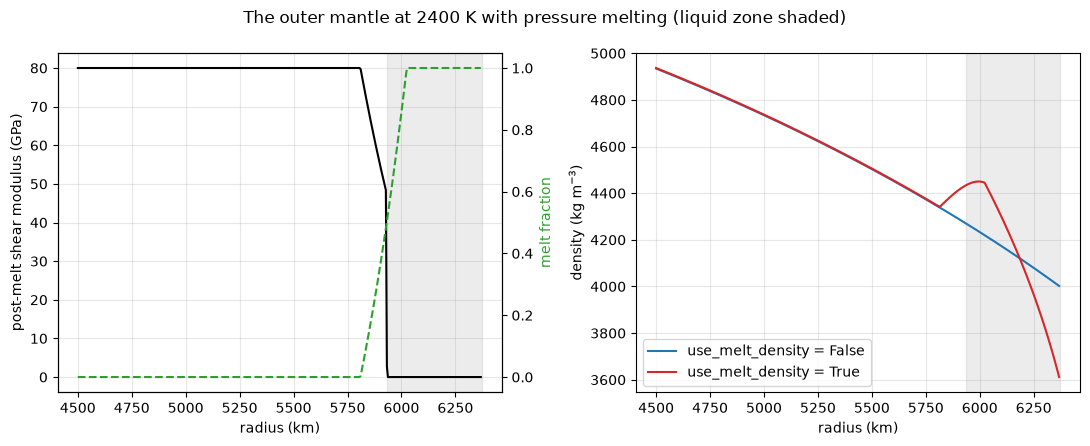

In [6]:
outer_radii = np.linspace(4500.0e3, 0.9995 * RADIUS, 400)
outer_km = outer_radii / 1.0e3
fig, (ax_mu, ax_rho) = plt.subplots(1, 2, figsize=(11, 4.5))
for melt_density, color in ((False, "tab:blue"), (True, "tab:red")):
    world = build_terrestrial(pressure_rock, temperature=2400.0, mass=bm_mass, use_melting=True,
                              use_pressure_melting=True, use_melt_density=melt_density)
    label = f"use_melt_density = {melt_density}"
    density = world.get_density(outer_radii)
    ax_rho.plot(outer_km, density, color=color, label=label)
    _, liquid_inner, liquid_outer = world.molten_regions[0]  # (layer name, inner radius, outer radius)
    if not melt_density:
        ax_mu.plot(outer_km, world.get_shear_modulus(outer_radii) / 1.0e9, "k")
        ax_phi = ax_mu.twinx()
        ax_phi.plot(outer_km, world.get_melt_fraction(outer_radii), color="tab:green", ls="--")
        ax_phi.set_ylabel("melt fraction", color="tab:green")
        for ax in (ax_mu, ax_rho):
            ax.axvspan(liquid_inner / 1.0e3, liquid_outer / 1.0e3, color="0.5", alpha=0.15)
    print(f"{label}: liquid zone {liquid_inner/1e3:.0f} to {liquid_outer/1e3:.0f} km, "
          f"mass {world.planet_mass_eos:.4e} kg, k2 = {love_k2(world).real:.3f}")
    # Where the density rises outward (denser material over lighter)
    rising = outer_radii[1:][np.diff(density) > 0.0]
    if rising.size > 0:
        print(f"    density rises outward from {rising[0]/1e3:.0f} km ({world.get_density(rising[0]):.0f} kg/m^3) "
              f"to {rising[-1]/1e3:.0f} km ({world.get_density(rising[-1]):.0f} kg/m^3)")
ax_mu.set_ylabel("post-melt shear modulus (GPa)")
ax_rho.set_ylabel("density (kg m$^{-3}$)")
ax_rho.legend()
for ax in (ax_mu, ax_rho):
    ax.set_xlabel("radius (km)"); ax.grid(alpha=0.3)
fig.suptitle("The outer mantle at 2400 K with pressure melting (liquid zone shaded)")
fig.tight_layout()
plt.show()

The world's mass is not refitted, so it follows whatever density the switches give. Turn `use_melt_density` on before fitting a world that melts. Notebook P13 follows a melting material point by point and adds the bulk-mixing laws, and notebook P10 lets the temperature itself vary with depth through a thermal solve.